Выполнил: Ашихмин Кирилл, группа P3124

# Предсказание дефолта по кредиту

Многие люди берут кредит в банке. Некоторые не отдают. Если просрочка по кредиту больше 90 дней, банк считает, по данному кредиту произошел дефолт, то есть клиент не в состоянии его отдать.

Одна из первых задач, которую решало машинное обучение в банках, - предсказание дефолта.
Нужно по данным, которые предоставил потенциальный заемщик, определить, будет у него дефолт или нет.

Задача предсказания дефолта - задача классификации, а результат работы модели для конкретного клиента - предсказать произойдет дефолт или нет.
В этой тетради мы рассмотрим вопрос измерения качества работы обученных
классификаторов. На примерах мы опишем различные метрики качества и способы
их подсчёта. Также обратим внимание на адекватность их использования в типичных
практических кейсах.

<img src="https://drive.google.com/uc?id=1jQX02vTP_BKJIRPamIDRQ2U1Ub1NONNH" alt="Drawing" style="width: 50px;" width="360"/>

Мы попробуем на данных из Kaggle соревнования _"Give me some credit"_ обучить модель машинного обучения, которая будет предсказывать дефолт.
https://www.kaggle.com/c/GiveMeSomeCredit#description

**Бизнес-постановка задачи**

Банк по анкетным данным оценивает вероятность того, что для конкретного клиента произойдет дефолт.
Применение модели ясно:
* мы хотим выдавать кредиты только хорошим заемщикам, которые отдадут кредит.

**Постановка задачи анализа данных**

Целью данной задачи является построение модели *классификации дефолтов*: на вход модель будет принимать данные о клиенте, а на выходе она должна работать в двух режимах:
* выдавать вероятность дефолта для данного клиента,
* выдавать правильный с точки зрения модели класс клиента (есть у него дефолт или нет).

Обучать модель мы будем по данным с платформы kaggle.

**Обзор доступных данных**

В выборке N наблюдений и 11 переменных, одна из которых - целевая.
Таким образом, про каждого из N клиентов мы знаем значения 11 их характеристик (возраст, доход в месяц), в том числе значение целевой переменной: есть ли у клиента сейчас просрочка более 90 дней.

Выборка была разбита на две части для обучения и для тестирования модели.

**Доступные признаки**

Данные содержат два типа переменных:

* Целевая: **SeriousDlqin2yrs**, есть ли просрочка 90 дней и более
* Остальные переменные: 10 переменных, могут использоваться для прогноза целевой переменной.

| Имя столбца        | Значение |
| :-------------: |:-------------:|
| SeriousDlqin2yrs      | **Целевая переменная:** Есть ли просрочка 90 дней и более |
| RevolvingUtilizationOfUnsecuredLines      | Доля использованных лимитов по кредитным картам     |
| age | Возраст заемщика в годах |
| DebtRatio | Отношение суммы долговой нагрузки, расходов на жизнь и алименты к доходу |
| MonthlyIncome | Доход в месяц |
| NumberOfOpenCreditLinesAndLoans | Количество открытых кредитов и кредитных линий (кредитных карт) |
| NumberRealEstateLoansOrLines | Количество ипотек и других кредитных продуктов, связанных с недвижимостью |
| NumberOfTime30-59DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 30-59 дней |
| NumberOfTime60-89DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 60-89 дней |
| NumberOfTimes90DaysLate | Сколько раз за последние 2 года у заемщика была просрочка более 90 дней |
| NumberOfDependents | Количество иждивенцев в семье (супруг, дети и т.п.) |



## План анализа данных (data mining):

  1. Загрузить данные для обучения
  2. Обработать данные перед обучением модели
  3. Обучить модель на обучающей выборке
  4. Загрузить и предобработать данные для тестирования
  5. Провалидировать модель на тестовой выборке

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

Для корректной работы с данными в python требуется загрузить специальную библиотеку
**pandas**, программную библиотеку на языке python для обработки и анализа данных.

Основная нагрузка по обработке входных данных ложится на модуль **pandas**. С
помощью функций `pandas.read_*` можно подтягивать данные из простых текстовых
файлов `CSV`, таблиц **Excel**, таблиц **HTML**, а также **SQL** запросами
из корпоративных баз данных и прочих распределённых хранилищ.

In [1]:
import pandas as pd

Для корректной работы с графиками в python требуется загрузить специальную библиотеку
**matplotlib**, программную библиотеку на языке python для визуализации данных двумерной и трехмерной графикой.

Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

Оснвные методы для построения:
* plot() - графики
* semilogy() - график логарифметический
* hist() - гистограммы

In [2]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt

Основную вычислительную нагрузку берёт на себя модуль **Numpy**, с помощью которого можно быстро производить
вычисления сразу над массивами чисел.

In [3]:
import numpy as np

Библиотека **scikit-learn** -- де факто наиболее популярный, разносторонний, хорошо
документированный и постоянно обогащающийся инструмент для построения моделей машинного
обучения.

Выберем из него:
* классификатор дерево решений (**DecisionTreeClassifier**);
* метод для удобной $k$*-fold* кросс-валидации (**KFold**);
* несколько готовых функции для расчёта метрик качества классификации.

In [4]:
from sklearn.tree import DecisionTreeClassifier # классификатор дерева решений

from sklearn.model_selection import KFold # k-folf кросс-валидация

from sklearn.metrics import roc_curve, precision_recall_curve, auc # метрики качества
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score # метрики качества
from sklearn.metrics import average_precision_score # метрики качества

Помимо задачи загрузки, расчётов и обучения моделей, немаловажную роль играет визуализация.
Она полезна как для предварительного анализа, так и для исследования метрик качеста, а также
упрощяет принятие решений и обобщение результатов.

Мы будем использовать библиотеку **MatplotLib**, которая отлично справляется с этой задачей.
Модуль **seaborn** устанавливет "приятные для глаз" палитры и стили для графиков.

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('whitegrid') # установить стиль whitegrid, другие стили можно найти в документации к seaborn

Некоторые библиотеки могут выводить на экран предупреждения, которые важно учитывать в "боевых" задачах. Но в учебной тетради мы укажем Python'у игнорировать их.

In [6]:
import warnings
warnings.filterwarnings("ignore")

<br/>

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные. Они состоят из двух частей: часть для обучения и часть для тестирования модели. Загружаем данные командой !curl: в отличие от wget, она есть и в Google Colab, и в macOS из коробки. Чтобы не засорять вывод сообщениями о ходе загрузки, ставим в первой строке магическую команду %%capture.

In [7]:
%%capture
# Скачиваем данные. curl есть и в Google Colab, и в macOS/Linux.
!curl -L -o training_data.csv "https://www.dropbox.com/s/io67uppgq66plbp/training_data.csv?dl=1"
!curl -L -o test_data.csv "https://www.dropbox.com/s/2ga9maqxbsf8xhg/test_data.csv?dl=1"


Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию **`pd.read_csv()`** из библиотеки `pandas`.

In [8]:
training_data = pd.read_csv('training_data.csv')


Посмотрим на 10 случайно выбранных записей из обучающего набора, для этого будем использовать функцию **sample()**. Параметр
**random_state=123** фиксирует "случайность", то есть на любом компьютере метод **sample()** будет работать одинаково.

In [9]:
# training_data.head(10)

training_data.sample(10)

training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         40147 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    48667 non-null  float64
dtypes: float64(4), int64(7)
me

**Шаг 1.3. Посмотрим общую статистику по данным**

Посмотрим на технические параметры загруженных данных для обучения. Для этого вызовем метод `describe()` для набора данных `training_data`

Для удобства отображения мы транспонируем результат: меняем местами столбцы и строки.

In [10]:
training_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,50000.0,0.066860,0.249782,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,50000.0,7.927880,332.393142,0.0,0.030096,0.154426,0.555651,50708.0
age,50000.0,52.240520,14.766593,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,50000.0,0.428220,4.269296,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,50000.0,352.441921,2006.426016,0.0,0.176304,0.366811,0.862599,329664.0
MonthlyIncome,40147.0,6642.232222,18122.708690,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,50000.0,8.476040,5.172756,0.0,5.000000,8.000000,11.000000,57.0
NumberOfTimes90DaysLate,50000.0,0.269920,4.243110,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,50000.0,1.017500,1.120151,0.0,0.000000,1.000000,2.000000,32.0
NumberOfTime60-89DaysPastDueNotWorse,50000.0,0.246040,4.231055,0.0,0.000000,0.000000,0.000000,98.0


Обратим внимание на общие статистики показателей в данных:
* **count** -- количество значений, которые не являются пропущенными (`NaN`);
* **mean**, **std** -- среднее и разброс данных в соответствующем поле;
* остальные статистики -- минимальное и максимальное значения, и квантили.

Из таких характеристик столбцов мы уже можем извлечь некоторую информацию о данных:
* У столбца **SeriousDlqin2yrs** среднее 0.060. Значит, в нашей выборке только у 6% клиентов есть дефолт.
* У столбца **MonthlyIncome** заполнено только 40147 из 50000. Минимальное значение дохода - 0, максимальное - 3008750.
* У столбца **NumberOfDependents** большое количество значений - нулевые.

## 2. Обработать данные перед обучением модели

**Шаг 2.1. Проверяем данные на наличие пропусков и типов переменных**

Начнем с проверки общей информации о данных.
Для того чтобы это сделать, нужно обратиться вызвать у переменной *training_data* метод **info()**.

Напомним, что info — метод, а значит необходимо поставить скобки.

In [11]:
# 1. Общая информация о таблице: типы столбцов и число заполненных значений.
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         40147 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    48667 non-null  float64
dtypes: float64(4), int64(7)
me

In [12]:
# Сколько пропусков в каждом столбце.
training_data.isnull().sum()

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           9853
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      1333
dtype: int64

Метод `info()` выводит информацию о таблице типа `pd.DataFrame`, включая формат `dtype` и `dtypes` столбца, ненулевые значения и использование памяти.

**Шаг 2.2. Заполнение пропусков**

Рассчитаем средние значения признаков в обучающей выборке, и заполним полученными
числами пропуски как в **тестовом наборе** данных, так и в **самой обучающей выборке**.

Мы будем заполнять средними значениями из обучающей выборки, так как при решении реальной задачи нам будут доступны только данные для обучения.

Для получения средних значений вызовем метод `mean()`. По умолчанию метод считает средним значения по столбцам. После выполнения ячейки средние значения записаны в переменной `train_mean`



In [13]:
# 2. Средние значения по каждому столбцу обучающей выборки.
train_mean = training_data.mean()
train_mean

SeriousDlqin2yrs                           0.066860
RevolvingUtilizationOfUnsecuredLines       7.927880
age                                       52.240520
NumberOfTime30-59DaysPastDueNotWorse       0.428220
DebtRatio                                352.441921
MonthlyIncome                           6642.232222
NumberOfOpenCreditLinesAndLoans            8.476040
NumberOfTimes90DaysLate                    0.269920
NumberRealEstateLoansOrLines               1.017500
NumberOfTime60-89DaysPastDueNotWorse       0.246040
NumberOfDependents                         0.756180
dtype: float64

Пропуски в данных можно заполнять и разными методами:
* выборочной статистикой (среднее, медиана);
* прогнозами регрессии по известыми признакам;
* случайными значениями.

Если относительно небольшая доля наблюдению имеет пропуски, то можно
вовсе исключить неполные наблюдения с пропущенными значениями из выборки.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый.

In [14]:
# 3. Заполняем пропуски в обучающей выборке средними значениями.
training_data.fillna(train_mean, inplace=True)
training_data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

**Шаг 2.3. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать дефолт, поэтому целевая переменная - это наличие дефолта.

In [15]:
target_variable_name = 'SeriousDlqin2yrs'

Обратим внимание на целевой признак **SeriousDlqin2yrs** -- наличие серьёзной просрочки
по кредитным выплатам за последние два года. Обычно заёмщики стараются производить выплаты
вовремя.

Чтобы посчитать количество хороших заемщиков без больших просрочек (значение переменной **SeriousDlqin2yrs** равно нулю) и плохих с просрочкой (значение **SeriousDlqin2yrs** равно единице) вызовем метод `value_counts()`

In [16]:
training_data[target_variable_name].value_counts()

SeriousDlqin2yrs
0    46657
1     3343
Name: count, dtype: int64

Нам нужно выделить в отдельную переменную *training_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *training_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [17]:
# 4. Целевая переменная — столбец с признаком дефолта.
training_values = training_data[target_variable_name]
training_values.head()

0    0
1    0
2    0
3    0
4    0
Name: SeriousDlqin2yrs, dtype: int64

Проверим размерность целевой переменной

In [18]:
training_values.shape

(50000,)

Запись `(50000,)` равносильна `(50000, 1)`.  Она означает, что у нас 50000 экземпляров в выборке и 1 признак

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным. Для это нужно у переменной training_data вызвать метод drop().

In [19]:
# 5. Входные признаки — все столбцы, кроме целевого.
# axis=1 означает "удалить столбец", а не строку.
training_points = training_data.drop(target_variable_name, axis=1)
training_points.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.250476,65,0,1963.000000,6642.232222,5,0,2,0,0.0
1,0.975402,58,0,0.049441,5905.000000,1,0,0,0,0.0
2,0.000000,82,0,0.000933,3215.000000,10,0,0,0,0.0
3,0.571491,36,0,0.113864,2300.000000,6,1,0,0,0.0
4,0.410499,45,0,0.478572,7816.000000,11,0,1,0,1.0


In [20]:
training_data.shape # (50000, 11)

(50000, 11)

In [21]:
training_points.shape # (50000, 10)

(50000, 10)

Видно, что столбца действительно нет, а количество строк не изменилось.

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.
Мы воспользуемся двумя методами для построения моделей классификации и сравним их между собой:
* Логистическая регрессия *logistic regression*
* Лес решающих деревьев *random forest*

Логистическая регрессия - "адаптация" линейной регрессии для решения задачи классификации. Она принадлежит к классу обобщенных линейных моделей.
А вот с помощью леса решающих деревьев можно хорошо решать и задачу регрессии, и задачу классификации.

Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Мы импортируем два модуля из этой библиотеки:
 * *linear_model* - тут находятся все линейные *и обобщенные линейные* модели, в том числе модель логистической регрессии.
 * *ensemble* - тут находятся модели на основе ансамблей.

In [22]:
from sklearn import linear_model, ensemble


Чтобы создать модель логистической регресии, пишем имя модуля 'linear_model', затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
logistic_regression_model = linear_model.logistic_regression_model()
logistic_regression_model
```

In [23]:
# 6. Создаём модель логистической регрессии.
# max_iter увеличен, чтобы алгоритм успел сойтись на этих данных.
logistic_regression_model = linear_model.LogisticRegression(max_iter=1000)
logistic_regression_model

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

Результат выполнения должен быть следующим:

```python
LogisticRegression(C=1.0, class_weight=None, dual=False,
          fit_intercept=True, intercept_scaling=1,
          max_iter=100, multi_class='warn', n_jobs=None,
          penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
```

In [24]:
logistic_regression_model

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

Модель логистической регрессии сложнее, чем модель линейной регрессии. Поэтому параметров у такой модели гораздо больше. Многие из них связаны с тем, с помощью какой процедуры мы будем подбирать параметры модели (*max_iter*, *dual*, *solver*, *tol*, *warm_start*), устойчивостью модели (*C*, *penalty*), тем, что мы решаем задачу классификации, а не регрессии (*class_weight*, *multi_class*)

Чтобы создать модель случайного леса, пишем имя модуля ensemble, затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
random_forest_model = ensemble.RandomForestClassifier()
random_forest_model
```

Код отличается от кода при решении задачи регрессии тем, что теперь нам нужна модель для классификации `RandomForestClassifier`, а не регрессии `RandomForestRegressor`.
Результат выполнения должен быть следующим:
    
```python
RandomForestClassifier(bootstrap=True, class_weight=None,
            criterion='gini', max_depth=None, max_features='auto',
            max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn',
            n_jobs=None, oob_score=False, random_state=None,
            verbose=0, warm_start=False)
```

Создадим модель в переменной ```random_forest_model``` с параметром ```n_estimators=100```.

In [25]:
# 7. Создаём модель случайного леса из 100 деревьев.
random_forest_model = ensemble.RandomForestClassifier(n_estimators=100)
random_forest_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
random_forest_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

У модели классификации на основе случайного леса больше параметров. Рассмотрим наиболее важные:
* параметр *n_estimators* определяет, сколько деревьев в лесу,
* в параметре *max_depth* устанавливается, какая максимальная глубина у дерева,
* в параметре *min_samples_leaf* задается, какое максимальное число объектов может попасть в лист дерева.

**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототипы обеих моделей, можем их обучить с помощью обучающей выборки.

Для этого вызываем метод **fit()** у каждой модели и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [27]:
# 8. Обучаем логистическую регрессию на обучающей выборке.
logistic_regression_model.fit(training_points, training_values)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

Делаем тоже самое для модели решающего леса.

Возможно, будут предупреждения, о том, что планируются изменения в будущем в этой модели (FutureWarning).

In [28]:
# 9. Обучаем случайный лес — метод тот же самый, fit().
random_forest_model.fit(training_points, training_values)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

* Для двух разных моделей в sklearn методы для обучения модели не отличаются.
* Мы получили две обученные модели.
* Теперь необходимо провалидировать модели на новых тестовых данных, которые не использовались при обучении модели.

## 4. Загрузить и предобработать данные для тестирования

**Шаг 4.1. Загрузим данные для тестирования**

Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию `pd.read_csv` из библиотеки `pandas`.

In [29]:
test_data = pd.read_csv('test_data.csv')

In [30]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 37500 entries, 0 to 37499
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      37500 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  37500 non-null  float64
 2   age                                   37500 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  37500 non-null  int64  
 4   DebtRatio                             37500 non-null  float64
 5   MonthlyIncome                         30044 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       37500 non-null  int64  
 7   NumberOfTimes90DaysLate               37500 non-null  int64  
 8   NumberRealEstateLoansOrLines          37500 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  37500 non-null  int64  
 10  NumberOfDependents                    36521 non-null  float64
dtypes: float64(4), int64(7)
me

In [31]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,37500.0,0.067387,0.250694,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,37500.0,6.031470,201.538421,0.0,0.029634,0.155112,0.565469,18300.0
age,37500.0,52.367387,14.769995,0.0,41.000000,52.000000,63.000000,107.0
NumberOfTime30-59DaysPastDueNotWorse,37500.0,0.448613,4.478678,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,37500.0,341.402289,1131.165077,0.0,0.173310,0.365951,0.866864,60212.0
MonthlyIncome,30044.0,6571.071295,7639.608316,0.0,3383.000000,5374.500000,8200.000000,562466.0
NumberOfOpenCreditLinesAndLoans,37500.0,8.428587,5.143302,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,37500.0,0.292667,4.458953,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,37500.0,1.020160,1.152043,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,37500.0,0.266160,4.444065,0.0,0.000000,0.000000,0.000000,98.0


**Шаг 4.2. Предобработка данных для тестирования**

Тестовые данные нужно предобработать аналогично обучающим. Поэтому заполним сперва пропуски в данных.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый

In [32]:
# 10. Пропуски в тестовых данных заполняем средними из обучающей выборки:
# в реальной задаче на момент обучения тестовых данных ещё нет.
test_data.fillna(train_mean, inplace=True)
test_data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

**Шаг 4.3. Отделяем целевую переменную**

Нам нужно выделить в отдельную переменную *test_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *test_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [33]:
# 11. Целевая переменная тестовой выборки.
test_values = test_data[target_variable_name]
test_values.shape

(37500,)

In [34]:
# 12. Входные признаки тестовой выборки.
test_points = test_data.drop(target_variable_name, axis=1)
test_points.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.166035,25,0,687.000000,6642.232222,9,0,0,0,0.0
1,1.036867,42,3,0.664400,5440.000000,12,0,2,0,3.0
2,0.100229,62,2,1.263068,3500.000000,11,0,2,0,0.0
3,0.232698,37,0,0.088482,3333.000000,5,0,0,0,0.0
4,0.950586,41,2,0.321115,11266.000000,6,1,1,0,0.0


И проверяем результат записанный в test_points

In [35]:
test_points.shape # (37500, 10)

(37500, 10)

# 5. Провалидировать модель на тестовой выборке

<img src="https://drive.google.com/uc?id=1QbHrix_UrbD77BmIGiitiaH8nB8UdUmj" alt="Drawing" style="width: 400px;"/>



Сначала получим прогноз модели на тестовых данных *`test_points`* с помощью моделей логистической регрессии и решающего леса.
Для этого для обеих моделей запустим метод **`predict()`**.

In [36]:
# 13. Прогноз меток классов логистической регрессией.
test_predictions_logistic_regression = logistic_regression_model.predict(test_points)
test_predictions_logistic_regression[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
# 14. Прогноз меток классов случайным лесом.
test_predictions_random_forest = random_forest_model.predict(test_points)
test_predictions_random_forest[:10]

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0])

Посмотрим, сколько предсказаний каждого вида (дефолтов и возвратов кредитов) спрогнозировали модели. Для этого необходимо вызвать функцию **`value_counts()`** из библиотеки **`pandas`** для полученных прогнозов.

In [38]:
# 15. Сколько нулей и единиц предсказала логистическая регрессия.
# predict() возвращает массив numpy, поэтому оборачиваем его в pd.Series.
pd.Series(test_predictions_logistic_regression).value_counts()

0    37298
1      202
Name: count, dtype: int64

Модель логистической регрессии предсказывает X неуплат и Y возвратов кредита в срок.  

In [39]:
# 16. То же самое для случайного леса.
pd.Series(test_predictions_random_forest).value_counts()

0    36606
1      894
Name: count, dtype: int64

Модель случайного леса предсказывает X' случаев неуплаты и Y' возврата кредита в срок.  

### Шаг 5.1. Точность прогноза

Естественный способ измерить качество модели - посчитать долю правильных предсказаний, то есть, сколько в процентном соотношении от размера тестовой выборки модель угадала единичек и сколько угадала ноликов. Такая метрика называется точность (accuracy).

<img src="https://drive.google.com/uc?id=1ITTp5pCtDKszhkkLXzXiuCWi09VJaioA" alt="Drawing" style="width: 600px;"/>

Функция для подсчета точности реализована в библиотеке **sklearn** и называется **`accuracy_score()`**. Импортируем её.

In [40]:
from sklearn.metrics import accuracy_score

В функцию **`accuracy_score()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_logistic_regression* или *test_predictions_random_forest*

In [41]:
# 17. Доля правильных ответов (accuracy) обеих моделей.
accuracy_logistic_regression = accuracy_score(test_values, test_predictions_logistic_regression)
accuracy_random_forest = accuracy_score(test_values, test_predictions_random_forest)

print("Accuracy логистической регрессии:", accuracy_logistic_regression)
print("Accuracy случайного леса:        ", accuracy_random_forest)

Accuracy логистической регрессии: 0.9331466666666667
Accuracy случайного леса:         0.9336266666666667


**Как понять, хорошо работает модель или нет?**

Из значения точности мы никак не можем понять, сколько меток каждого класса правильно предсказала модель. В нашей задаче мало значений с классом 1 (дефолт), но много 0 (возврат кредита). Может быть такая ситуация, когда модель очень хорошо научилась выделять характеристики большого класса, в нашем случае 0, но совсем не умеет выделять характеристики маленького класса. А часто именно последние в большей степени интересуют аналитиков.

Самый простой способ проверить - это сравнить значения точности для наших моделей с точностью для константного классификатора, модели, которая всегда бы предсказывала больший класс, в нашем случае 0.
Для этого можно в функцию **`accuracy_score()`** в качестве второго аргумента передать массив нулей такого же размера, как и *test_values*. Это делается с помощью функции **`zeros_like()`** из библиотеки numpy, у которой один аргумент - *test_values*, массив с размером которого будет создан массив нулей.

In [42]:
# 18. Константный классификатор: всегда предсказываем 0 (самый частый класс).
constant_predictions = np.zeros_like(test_values)
accuracy_constant = accuracy_score(test_values, constant_predictions)

print("Accuracy константного классификатора:", accuracy_constant)
print("Accuracy логистической регрессии:    ", accuracy_logistic_regression)
print("Accuracy случайного леса:            ", accuracy_random_forest)

Accuracy константного классификатора: 0.9326133333333333
Accuracy логистической регрессии:     0.9331466666666667
Accuracy случайного леса:             0.9336266666666667


Действительно, для логистической регрессии точность очень близка к точности константного классификатора. Это не означает, что логистическая регрессия работает определенно плохо, но необходимо проверить дополнительные метрики.

### Шаг 5.2. Таблица сопряженности модели классификации

Другой способ оценивать качество работы классификатора - использовать таблицу сопряженности.

**Таблица сопряжённости** (матрица неточности, или Confusion matrix) содержит сводные показатели качества работы классификатора. **Строки** этой таблицы соответствуют **фактическим классам** тестового набора, а **столбцы** - **предсказанным** классификатором меткам.

Импортируем функцию для построения таблицы сопряженности из библиотеки **`sklearn`**.

In [43]:
from sklearn.metrics import confusion_matrix

Таблица содержит четыре сводных показателя, каждый из которых отражает количество объектов в одной и четырех
категорий:
* **истинно позитивный** (*True positive*, **TP**) -- объект
класса `1` был верно помечен меткой `1`;
* **ложно позитивный** (*False positive*, **FP**) -- объект
фактически принадлежит классу `0`, но помечен меткой `1`;
* **истинно отрицательный** (*True negative*, **TN**) -- классификатор
верно определил, что объект класса `0` принадлежит классу `0`;
* **ложно отрицательный** (*False negative*, **FN**) -- классификатор
пометил объект меткой `0`, однако на самом деле объект принадлежит классу `1`.


Замечание: ошибки False positive часто называют **ложной тревогой**, а False negative - **пропуском цели**.

|                   |  Предсказано `0` |  Предсказано `1` |
|:-------------------|:------------------|:------------------|
|**Фактически** `0`  |       TN         |       FP         |
|**Фактически** `1`  |       FN         |       TP         |

Посмотрим на таблицу сопряженности для логистической регрессии и случайного леса. Для этого в функцию **`confusion_matrix()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_random_forest* и аналогично для второй модели — *test_predictions_logistic_regression*

Далее для удобства мы запишем полученную матрицу в удобный табличный вид, воспользовавшись функцией **`DataFrame()`** из библиотеки **pandas**.

In [44]:
# 19. Таблица сопряжённости для логистической регрессии.
logistic_regression_confusion_matrix = confusion_matrix(
    test_values, test_predictions_logistic_regression
)
logistic_regression_confusion_matrix = pd.DataFrame(logistic_regression_confusion_matrix)

logistic_regression_confusion_matrix

,0,1
0,34882,91
1,2416,111


In [45]:
# 20. Таблица сопряжённости для случайного леса.
random_forest_confusion_matrix = confusion_matrix(
    test_values, test_predictions_random_forest
)
random_forest_confusion_matrix = pd.DataFrame(random_forest_confusion_matrix)

random_forest_confusion_matrix

,0,1
0,34545,428
1,2061,466


Разберем полученные значения подробнее:

<img src="https://drive.google.com/uc?id=1xBlpY2UwXy94IYxAme4OXZxxaNm57A3x" alt="Drawing" style="width: 400px;" width="700"/>


Почему значения на картинке могут отличаются от тех, которые мы получили?

`random_seed` не был зафиксирован в модели Случайных лесов, и мы видим незначительные отклонения в результатах предсказания.

### Шаг 5.3. Прогноз вероятности принадлежности к классу

Вместо прогноза меток классов модель может с помощью метода **`predict_proba()`** выдавать метки вероятности принадлежности к классам.
Так как класса у нас 2: заемщики с дефолтом и без, то матрица будет размером **(количество объектов в тестовой выборке, 2)**.

In [46]:
test_probabilities = logistic_regression_model.predict_proba(test_points)

Посмотрим на первые пять значений этой матрицу:

In [47]:
test_probabilities[:5, :]

array([[0.89609568, 0.10390432],
       [0.69064572, 0.30935428],
       [0.90271362, 0.09728638],
       [0.91456485, 0.08543515],
       [0.79465578, 0.20534422]])

Вероятность принадлежности ко второму классу - во втором столбце матрицы вероятностей.

In [48]:
test_probabilities = test_probabilities[:, 1]

Посмотрим на распределение предсказанной классификатором вероятности дефолта, метки `1`.

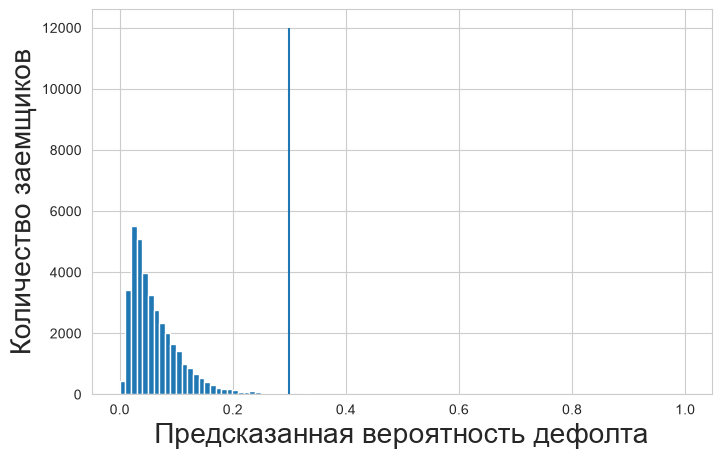

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(test_probabilities, bins=100)
plt.vlines(0.3, 0, 12000)

plt.xlabel('Предсказанная вероятность дефолта', fontsize=20)
plt.ylabel('Количество заемщиков', fontsize=20);

Распределение сконцентрировано на отрезке от `0` до `0.3` и лишь незначительная часть вероятностей превышает порог `0.5`. Из
этого можно предположить, что классификатор склонен классифицировать все
объекты скорее как `0`, игнорируя метку `1`. Это происходит потому, что меток `1` в обучающей выборке сильно меньше, чем меток `0`.

### Шаг 5.4. Выбор порога классификатора

На самом деле, при вызове метода **`predict()`** классификатор преобразует полученные вероятности в метки. По умолчанию для этого используется сравнение с порогом $0.5$: если вероятность объекта меньше порога, то этот объект относится к классу 0, если больше - к классу 1.  

По умолчанию классификатор использует порог $0.5$, чтобы из вероятностей принадлежности к классу сделать метки классов.  

**За что отвечает порог классификатора?**

Порог классификатора контролирует соотношение между количеством False positive и False negative. Если мы задаем слишком высокий порог классификатора, то он редко предсказывает 1, но часто 0, таким образом, увеличивается количество False negative и уменьшается количество False positive. Если же порог низкий - мы часто предсказываем 1, а 0 реже, значит увеличивается количество False positive и уменьшается False negative.

Что это значит в нашей задаче кредитного скоринга? Если порог высокий, то мы реже считаем клиентов подозрительными и чаще выдаем клиентам кредит. В этом случае банк может потерять много денег из-за невозвратов. Если же порог низкий, то мы чаще считаем клиентов подозрительными и выдаем мало кредитов. Очевидно, это тоже плохо, так как мы часто не выдаем кредиты честным клиентам, что отражается на прибыли банка.

Посмотрим на то, как влияет порог на матрицу сопряженности.  

In [50]:
higher_thershold = 0.7
alternative_test_predictions = test_probabilities > higher_thershold


In [51]:
alternative_confusion_matrix = pd.DataFrame(confusion_matrix(test_values, alternative_test_predictions))
alternative_confusion_matrix

,0,1
0,34939,34
1,2491,36


Действительно, количество ложно-отрицательных (False negative) срабатываний увеличилось, а количество ложно-положительных срабатываний (False positive) уменьшилось.

**Задание:** получите confusion matrix для уменьшенного значения порога 0.3

In [52]:
# 21. Confusion matrix для пониженного порога 0.3 (логистическая регрессия).
# Порог ниже -> чаще предсказываем 1 -> больше False positive, меньше False negative.
lower_threshold = 0.3
lower_threshold_predictions = test_probabilities > lower_threshold

pd.DataFrame(confusion_matrix(test_values, lower_threshold_predictions))

,0,1
0,34695,278
1,2255,272


In [53]:
# 22. Confusion matrix для порогов 0.3, 0.5 и 0.7 для случайного леса.
random_forest_probabilities = random_forest_model.predict_proba(test_points)[:, 1]

for threshold in [0.3, 0.5, 0.7]:
    predictions = random_forest_probabilities > threshold
    matrix = pd.DataFrame(confusion_matrix(test_values, predictions))
    print(f"Порог = {threshold}")
    print(matrix)
    print()

Порог = 0.3
       0     1
0  33588  1385
1   1548   979

Порог = 0.5
       0    1
0  34545  428
1   2061  466

Порог = 0.7
       0    1
0  34907   66
1   2406  121



### *Бонус:  ROC кривая классификатора

Если хотят сравнить метрики на разных наборах данных, обычно работают не с абсолютными значениями True Positive и False Positive, а с их долями:

* Доля ложноположительных срабатываний $\text{FPR} = \frac{FP}{FP + TN}$;
* Доля истинно положительных срабатываний $\text{TPR} = \frac{TP}{TP + FN}$.

Заметим, что $FP + TN$ дает общее число объектов класса $0$, а $TP + FN$ - общее число объектов класса $1$.

Одной из самых популярных метрик для задачи классификации является ROC кривая. ROC расшифровывается как *Receiver Operating Characteristic*. Эта кривая наглядно показывает зависимость доли истинно позитивных срабатываний (**TPR**) от доли ложно позитивных срабатываний (**FPR**) при изменении порога классификации.

Функция **roc_curve()** из **scikit-learn** позволяет получить координаты точек ROC кривой, а также значения порога **threshold**, при котором достигается соответствующие значения метрик **FPR** и **TPR**.

На вход функции **roc_curve()** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* вероятности, предсказанные моделью - *test_probabilities*

In [54]:
# 23. Координаты точек ROC-кривой для логистической регрессии.
# test_probabilities сейчас содержит вероятность класса 1 (см. ячейку выше).
false_positive_rates, true_positive_rates, threshold = roc_curve(
    test_values, test_probabilities
)

print("Точек на кривой:", len(false_positive_rates))

Точек на кривой: 4406


Нарисуем кривую

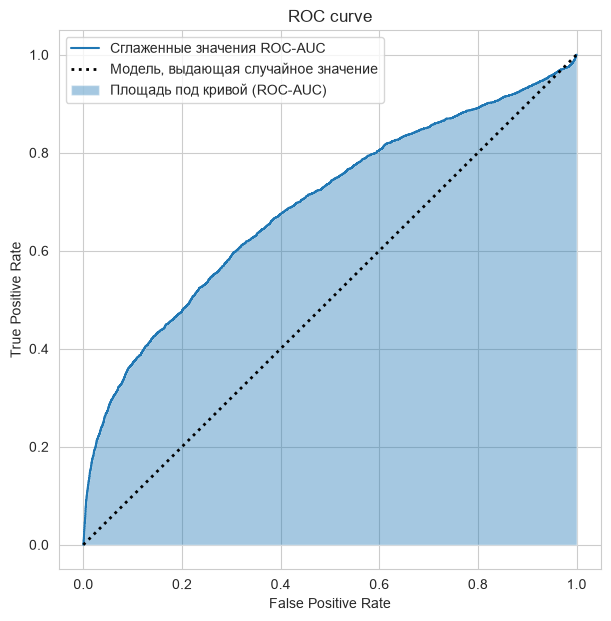

In [55]:
# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="mid", alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

Чем ближе в целом кривая **ROC** к **левому верхнему** углу, тем лучше качество классификации.

Несмотря на наглядность, иногда требуется некоторое число, обобщающее весь
график. Для ROC кривой таким числом является "площадь под кривой" (**ROC-AUC**).

В **sklearn** есть специальная функция **roc_auc_score()** для подсчёта
площади под ROC-кривой.

In [56]:
from sklearn.metrics import roc_auc_score

Типичная шкала для **ROC-AUC** (часто все зависит от задачи):
* $0.90$ - $1.00$ отлично;
* $0.80$ - $0.90$ хорошо;
* $0.70$ - $0.80$ удовлетворительно;
* $0.60$ - $0.70$ плохо;
* $0.50$ - $0.60$ очень плохо;
* $0.00$ - $0.50$ классификатор перепутал метки.

Вычислите значения *roc_auc_value* для обеих моделей

In [57]:
# 24. ROC-AUC логистической регрессии.
test_probabilities = logistic_regression_model.predict_proba(test_points)[:, 1]
roc_auc_value = roc_auc_score(test_values, test_probabilities)

print("ROC-AUC логистической регрессии на тестовой выборке:", roc_auc_value)

ROC-AUC логистической регрессии на тестовой выборке: 0.6908952070674771


In [58]:
# 25. ROC-AUC случайного леса.
test_probabilities = random_forest_model.predict_proba(test_points)[:, 1]
roc_auc_value = roc_auc_score(test_values, test_probabilities)

print("ROC-AUC случайного леса на тестовой выборке:", roc_auc_value)

ROC-AUC случайного леса на тестовой выборке: 0.8396066145028087


Выведите график ROC-AUC для алгоритма Random Forest. Попробуйте проанализировать параметры модели и добиться значения ROC-AUC ≥ 0.9

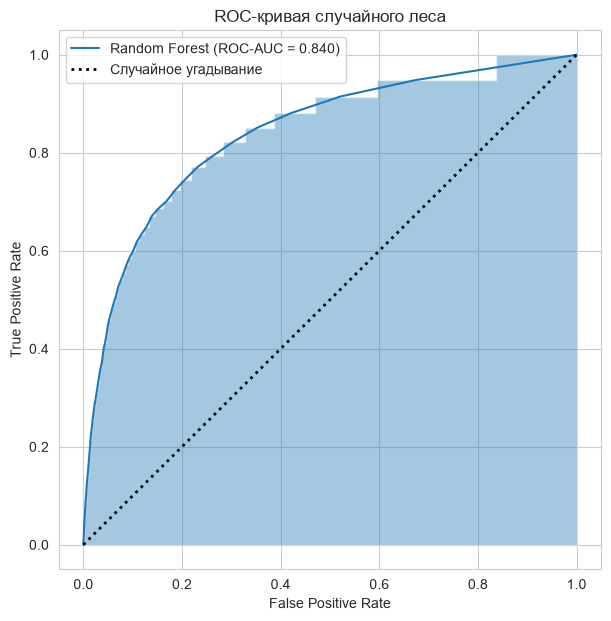

{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} -> ROC-AUC = 0.8394


{'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 1} -> ROC-AUC = 0.8616


{'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 20} -> ROC-AUC = 0.865


{'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 50} -> ROC-AUC = 0.8648


,n_estimators,max_depth,min_samples_leaf,roc_auc
2,200,10.0,20,0.8650
3,300,12.0,50,0.8648
1,200,6.0,1,0.8616
0,100,NaN,1,0.8394


In [59]:
# 26. ROC-кривая случайного леса и подбор параметров.

# --- сначала рисуем кривую для уже обученной модели ---
rf_probabilities = random_forest_model.predict_proba(test_points)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(test_values, rf_probabilities)
rf_auc = roc_auc_score(test_values, rf_probabilities)

plt.figure(figsize=(7, 7))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (ROC-AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], color="k", lw=2, linestyle=":", label="Случайное угадывание")
plt.title("ROC-кривая случайного леса")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.fill_between(fpr_rf, tpr_rf, step="mid", alpha=0.4)
plt.legend()
plt.show()


# --- теперь пробуем подобрать параметры и поднять ROC-AUC ---
# Основная проблема леса "из коробки" — деревья растут до конца и переобучаются.
# Ограничиваем глубину и минимальный размер листа.
parameter_sets = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},    # текущая модель
    {"n_estimators": 200, "max_depth": 6, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 20},
    {"n_estimators": 300, "max_depth": 12, "min_samples_leaf": 50},
]

results = []
for parameters in parameter_sets:
    model = ensemble.RandomForestClassifier(random_state=42, n_jobs=-1, **parameters)
    model.fit(training_points, training_values)
    auc = roc_auc_score(test_values, model.predict_proba(test_points)[:, 1])
    results.append({**parameters, "roc_auc": round(auc, 4)})
    print(parameters, "-> ROC-AUC =", round(auc, 4))

pd.DataFrame(results).sort_values("roc_auc", ascending=False)

# Самостоятельная работа


## Пункт 3.

> Исследуйте другие модели для реализации классификации значений. Постарайтесь построить более точную модель, модель, имеющую ошибку, меньшую чем в рассматриваемых в борде (например, SVM, kNN). При невозможности получить более точную модель, используйте LLM инструменты для того чтобы это сделать (альтернативно: опишите с помощью LLM, почему это сделать невозможно).


Сравним несколько разных классификаторов на одних и тех же данных.

Смотрим на ROC-AUC, потому что классы сильно несбалансированы
(дефолтов около 6.7%) и accuracy здесь неинформативна: константный классификатор,
всегда предсказывающий 0, уже даёт accuracy ≈ 0.93.

Что важно учесть:

* kNN и SVM чувствительны к масштабу признаков. У нас `MonthlyIncome`
  измеряется тысячами, а `NumberOfDependents` — единицами. Без нормировки
  расстояние между объектами будет определяться почти только доходом. Поэтому
  эти модели оборачиваем в `Pipeline` вместе со `StandardScaler`.
* У наших признаков огромный перекос (skew). Посмотрим на него отдельно —
  это окажется важнее, чем сам масштаб.
* SVM с RBF-ядром на 50 000 объектов обучается часами (сложность около
  O(n²)), поэтому берём линейный `LinearSVC`.
* Деревьям и лесам преобразования признаков не нужны: они сравнивают признак с
  порогом, а не считают расстояния.

In [60]:
# Посмотрим на асимметрию распределений (skew).
# У нормального распределения skew = 0; значения больше 1 говорят о сильном
# перекосе, а десятки — о тяжёлом "хвосте" из выбросов.
training_points.skew().sort_values(ascending=False).round(1)

MonthlyIncome                           145.2
DebtRatio                                97.0
RevolvingUtilizationOfUnsecuredLines     94.3
NumberOfTime60-89DaysPastDueNotWorse     22.9
NumberOfTimes90DaysLate                  22.7
NumberOfTime30-59DaysPastDueNotWorse     22.2
NumberRealEstateLoansOrLines              3.0
NumberOfDependents                        1.6
NumberOfOpenCreditLinesAndLoans           1.2
age                                       0.2
dtype: float64

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier


def evaluate_model(name, model):
    """Обучить модель и посчитать три метрики на тестовой выборке."""
    model.fit(training_points, training_values)
    predictions = model.predict(test_points)

    # Для ROC-AUC нужны не метки, а "уверенность" модели.
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(test_points)[:, 1]
    else:
        scores = model.decision_function(test_points)

    return {
        "модель": name,
        "accuracy": round(accuracy_score(test_values, predictions), 4),
        "f1": round(f1_score(test_values, predictions), 4),
        "roc_auc": round(roc_auc_score(test_values, scores), 4),
    }

In [62]:
from sklearn.preprocessing import QuantileTransformer

models = {
    "Логистическая регрессия (как в борде)":
        linear_model.LogisticRegression(max_iter=1000),

    "Логистическая регрессия + StandardScaler":
        make_pipeline(StandardScaler(), linear_model.LogisticRegression(max_iter=1000)),

    "Логистическая регрессия + QuantileTransformer":
        make_pipeline(
            QuantileTransformer(output_distribution="normal", random_state=42),
            linear_model.LogisticRegression(max_iter=1000)),

    "kNN (k=25) + StandardScaler":
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=25, n_jobs=-1)),

    "Линейный SVM + StandardScaler":
        make_pipeline(StandardScaler(), LinearSVC(C=0.01, max_iter=5000)),

    "Случайный лес (как в борде)":
        ensemble.RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),

    "Случайный лес (подобранные параметры)":
        ensemble.RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=20,
            random_state=42, n_jobs=-1),

    "Градиентный бустинг (HistGradientBoosting)":
        HistGradientBoostingClassifier(random_state=42),
}

comparison = [evaluate_model(name, model) for name, model in models.items()]
comparison = pd.DataFrame(comparison).sort_values("roc_auc", ascending=False)
comparison

,модель,accuracy,f1,roc_auc
6,Случайный лес (подобранные параметры),0.9355,0.2280,0.8650
7,Градиентный бустинг (HistGradientBoosting),0.9355,0.2740,0.8622
2,Логистическая регрессия + QuantileTransformer,0.9349,0.2569,0.8398
5,Случайный лес (как в борде),0.9341,0.2730,0.8394
3,kNN (k=25) + StandardScaler,0.9335,0.0944,0.7305
0,Логистическая регрессия (как в борде),0.9331,0.0813,0.6909
1,Логистическая регрессия + StandardScaler,0.9329,0.0757,0.6900
4,Линейный SVM + StandardScaler,0.9327,0.0389,0.6871


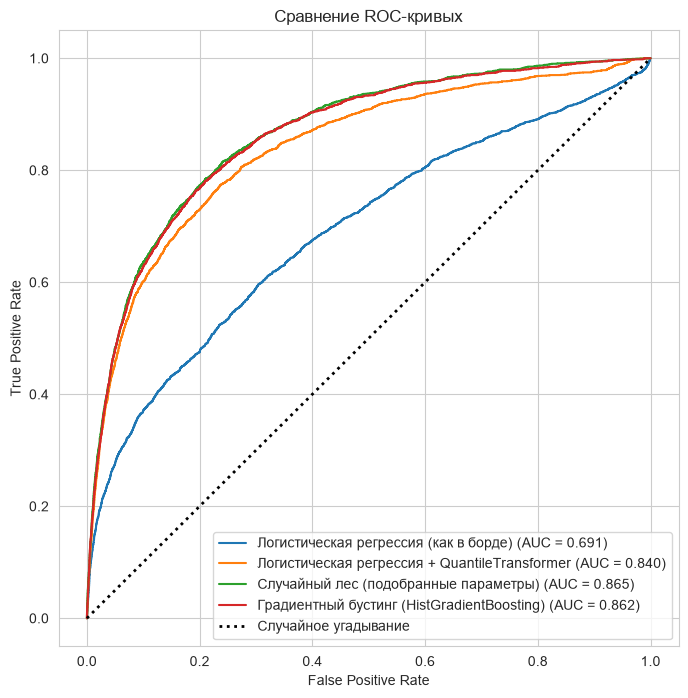

In [63]:
# Нарисуем ROC-кривые самых показательных моделей на одном графике.
plt.figure(figsize=(8, 8))

for name in ["Логистическая регрессия (как в борде)",
             "Логистическая регрессия + QuantileTransformer",
             "Случайный лес (подобранные параметры)",
             "Градиентный бустинг (HistGradientBoosting)"]:
    model = models[name]
    scores = model.predict_proba(test_points)[:, 1]
    fpr, tpr, _ = roc_curve(test_values, scores)
    auc_value = roc_auc_score(test_values, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], color="k", lw=2, linestyle=":", label="Случайное угадывание")
plt.title("Сравнение ROC-кривых")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### Выводы по пункту 3

1. Лучший результат дали ансамбли деревьев — настроенный случайный лес
(ROC-AUC ≈ 0.865) и градиентный бустинг (≈ 0.862). Они идут практически
вровень, разница в третьем знаке и в пределах случайной погрешности.
Это ожидаемо: зависимость между анкетными признаками и дефолтом нелинейная,
а деревья умеют её улавливать.

2. Самый неожиданный результат — про логистическую регрессию.

| Вариант | ROC-AUC |
|---|---|
| без преобразования | ≈ 0.691 |
| + `StandardScaler` | ≈ 0.690 |
| + `QuantileTransformer` | ≈ 0.840 |

`StandardScaler` не помог вообще, а `QuantileTransformer` поднял качество
почти на 0.15. Причина видна в ячейке со `skew()`: у признаков
`MonthlyIncome`, `DebtRatio` и `RevolvingUtilizationOfUnsecuredLines`
асимметрия равна 145, 97 и 94 — при нуле у нормального распределения.
То есть у них чудовищно тяжёлый «хвост» из выбросов (доход до 3 млн,
DebtRatio до 300 000).

`StandardScaler` вычитает среднее и делит на стандартное отклонение — это
линейное преобразование. Оно меняет масштаб, но не меняет форму
распределения: выбросы как были в сотни раз дальше остальных точек, так и
остаются, и продолжают «тянуть» на себя коэффициенты модели.
`QuantileTransformer` работает иначе: он заменяет значение на его ранг в
выборке и растягивает результат в нормальное распределение. Выбросы при этом
превращаются просто в «самые большие значения», и линейная модель наконец
начинает работать.

Вывод, который стоит запомнить: для линейных моделей важен не масштаб
признаков сам по себе, а форма их распределения.

3. kNN и линейный SVM оказались слабее. kNN (≈ 0.73) страдает от того же
перекоса — он считает евклидовы расстояния, а их определяют выбросы. Линейный
SVM (≈ 0.69) проводит одну разделяющую гиперплоскость, и упирается ровно в то
же ограничение, что и логистическая регрессия без преобразования.

4. Низкий F1 у всех моделей (0.04-0.27) — прямое следствие дисбаланса.
При пороге 0.5 модели почти никогда не предсказывают класс 1, поэтому recall
низкий. Лечится это не сменой алгоритма, а понижением порога (шаг 5.4) или
`class_weight="balanced"`.

5. Про требование ROC-AUC ≥ 0.9 из шага 26. Дотянуть до 0.9 не вышло ни
одной моделью. Для ориентира: в соревновании Kaggle *Give Me Some Credit*,
откуда взяты данные, победитель получил около 0.869.

Сравнивать напрямую эти числа нельзя. У нас урезанная выборка (50 000 строк
обучения вместо 150 000 у организаторов), свой случайный сплит и своя тестовая
часть, а на Kaggle счёт шёл по закрытому лидерборду. Так что 0.865 не означает
«уровень призёров», это просто цифра того же порядка.

Но порядок сам по себе о чём-то говорит. Похоже, ограничение сидит в данных, а
не в алгоритме: десяти анкетных признаков не хватает, чтобы отделить будущие
дефолты точнее. Поднять качество можно было бы новыми источниками (история
платежей, транзакции, данные бюро кредитных историй), а перебор моделей тут
упирается в потолок: разброс ROC-AUC между восемью вариантами оказался меньше
0.18, и лучшие три отличаются в третьем знаке.

## Пункт 4. Какие алгоритмы классификации используются сейчас

Если посмотреть на разборы решений на Kaggle (например,
[Comparing ML Models for Classification](https://www.kaggle.com/code/adoumtaiga/comparing-ml-models-for-classification))
и на обзорные публикации, картина для табличных данных такая.

1. Градиентный бустинг над деревьями — фактический стандарт.
Три основные реализации:

| Библиотека | Особенность |
|---|---|
| XGBoost | Самая известная, много регуляризации, хорошо документирована |
| LightGBM | Растит деревья «по листьям», очень быстрая на больших выборках |
| CatBoost | Разработка Яндекса, сама обрабатывает категориальные признаки |

В scikit-learn есть встроенный аналог — `HistGradientBoostingClassifier`
(его мы и использовали выше), построенный по тем же идеям, что LightGBM.

2. Классические модели никуда не делись. Логистическая регрессия остаётся
базовой моделью в банковском скоринге: она интерпретируема — по весам видно,
какой признак и насколько увеличивает риск. Это важно, потому что регуляторы
требуют объяснять отказ в кредите. Часто её используют как baseline, с которым
сравнивают всё остальное.

3. Нейронные сети доминируют там, где данные неструктурированы: тексты,
изображения, звук. Для табличных данных они обычно проигрывают бустингу —
это подтверждено большим сравнением Grinsztajn et al., *«Why do tree-based
models still outperform deep learning on tabular data?»* (NeurIPS 2022).

4. Работа с дисбалансом классов — отдельная большая тема, и в нашей задаче
она определяет всё остальное. Основные приёмы:

* `class_weight="balanced"` — штрафовать ошибки на редком классе сильнее;
* SMOTE — генерация синтетических объектов редкого класса;
* подбор порога классификации под бизнес-задачу вместо стандартных 0.5
  (именно это мы делали на шаге 5.4).

5. Интерпретируемость. Поверх «чёрных ящиков» применяют SHAP и LIME —
методы, которые показывают вклад каждого признака в конкретное предсказание.
В кредитном скоринге это обязательное требование.

## Пункт 5. Как интегрировать обученную модель в веб-сервис

Пошаговый алгоритм на примере FastAPI (для Flask шаги те же, отличается
только синтаксис).

Шаг 1. Сохранить обученную модель в файл.
Модель обучается один раз, а веб-сервис должен уметь её просто загрузить.
Используется `joblib` (он эффективнее `pickle` для больших numpy-массивов):

```python
import joblib
joblib.dump(model, "model.joblib")
```

Важно сохранять весь `Pipeline` целиком, вместе со `StandardScaler`.
Иначе на проде данные не будут нормированы так же, как при обучении, и
предсказания окажутся мусором.

Шаг 2. Зафиксировать версии библиотек.
Модель, сохранённая в scikit-learn 1.5, может не загрузиться в 1.2.
Поэтому версии фиксируются в `requirements.txt` / `pyproject.toml`.

Шаг 3. Описать схему входных данных.
В FastAPI это делается через `pydantic` — библиотека сама проверит типы и
вернёт понятную ошибку 422, если клиент прислал что-то не то:

```python
from pydantic import BaseModel

class Client(BaseModel):
    RevolvingUtilizationOfUnsecuredLines: float
    age: int
    DebtRatio: float
    MonthlyIncome: float
    # ... остальные признаки
```

Шаг 4. Загрузить модель один раз при старте приложения.
Загружать её внутри обработчика запроса нельзя — файл будет читаться с диска
на каждый запрос, и сервис станет очень медленным.

```python
from fastapi import FastAPI

app = FastAPI()
model = joblib.load("model.joblib")   # выполняется один раз при запуске
```

Шаг 5. Написать эндпоинт предсказания.

```python
import pandas as pd

@app.post("/predict")
def predict(client: Client):
    # Модель обучалась на DataFrame, поэтому и на вход подаём DataFrame
    # с теми же именами и в том же порядке столбцов.
    features = pd.DataFrame([client.model_dump()])
    probability = model.predict_proba(features)[0, 1]
    return {
        "default_probability": float(probability),
        "decision": "отказать" if probability > 0.3 else "одобрить",
    }
```

Возвращаем вероятность, а не только метку. Порог —
это бизнес-решение, и его удобно менять без переобучения модели.

Шаг 6. Добавить проверку работоспособности.

```python
@app.get("/health")
def health():
    return {"status": "ok"}
```

Нужен для мониторинга и для балансировщика нагрузки.

Шаг 7. Запустить сервер.

```bash
uvicorn main:app --host 0.0.0.0 --port 8000
```

FastAPI автоматически сгенерирует документацию на `/docs`, где API можно
потыкать руками.

Шаг 8. Упаковать в Docker.
Образ гарантирует одинаковое окружение на машине разработчика и на сервере:

```dockerfile
FROM python:3.12-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
```

Шаг 9. Логирование и мониторинг.
Записывать входные данные и предсказания, чтобы отслеживать data drift —
ситуацию, когда поток реальных заявок со временем перестаёт быть похожим на
обучающую выборку и качество модели незаметно падает.

Шаг 10. Переобучение.
Настроить регулярное переобучение на свежих данных и хранить версии моделей
(например, в MLflow), чтобы можно было откатиться на предыдущую.